In [ ]:
# Data Inspection
import pandas as pd
from pathlib import Path

# Metrics tracking for model comparison
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Dictionary to store all model results
model_results = {
    'Model': [],
    'MAE': [],
    'RMSE': [],
    'MAPE': []
}

def calculate_metrics(y_true, y_pred, model_name):
    """Calculate and store all metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    model_results['Model'].append(model_name)
    model_results['MAE'].append(mae)
    model_results['RMSE'].append(rmse)
    model_results['MAPE'].append(mape)

    print(f"\n{model_name} Metrics:")
    print(f"MAE:  {mae:.2f} kWh")
    print(f"RMSE: {rmse:.2f} kWh")
    print(f"MAPE: {mape:.2f}%")

    return mae, rmse, mape

# Define root directory and subdirectories relative to the current working directory
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "output"

# Use DATA_DIR for dataset path
data_path = DATA_DIR / "nsp_electricity_dataset.csv"

# Refined read_csv call with additional parameters for handling dataset structure

In [ ]:
df = pd.read_csv(
    data_path,
    parse_dates=['timestamp'],  # Parse 'timestamp' column as datetime
    index_col='timestamp',     # Set 'timestamp' as the index
    dayfirst=False,            # Ensure dates are in MM/DD/YYYY format
    low_memory=False,          # Optimize memory usage for large datasets
    na_values=['?', 'NA', ''], # Handle missing values
    dtype={                    # Specify data types for columns
        'region': 'category',
        'consumption_kwh': 'float32'
    }
)

# Display dataset information
print(f"Dataset Shape: {df.shape}")
print(f"Dataset Columns: {df.columns.tolist()}")
print(f"First 5 Rows:\n{df.head()}")
print(f"Data Types:\n{df.dtypes}")

# Check date range of timestamp column
print(f"Date Range: {df.index.min()} to {df.index.max()}")

# Check for missing values
print(f"Missing Values:\n{df.isnull().sum()}")


## Loading and Inspecting the Dataset
This section loads the dataset `nsp_electricity_dataset.csv` and inspects its structure. It includes:
- Parsing the `timestamp` column as datetime.
- Setting `timestamp` as the index.
- Handling missing values and optimizing memory usage.


In [ ]:
# Filter data for Halifax and prepare for Prophet
halifax_data = df[df['region'] == 'Halifax']

# Prepare data for Prophet
prophet_data = halifax_data[['consumption_kwh']].reset_index()
prophet_data.rename(columns={'timestamp': 'ds', 'consumption_kwh': 'y'}, inplace=True)

# Display the first few rows of prepared data
print(prophet_data.head())


### Dataset Inspection Results
- **Shape**: 438,360 rows and 26 columns.
- **Columns**: Includes `region`, `hour`, `day_of_week`, `month`, `year`, `week`, `is_weekend`, `season`, `is_holiday`, `temperature_c`, `consumption_kwh`, etc.
- **Date Range**: From `2015-01-01 00:00:00` to `2024-12-31 23:00:00`.
- **Missing Values**: None across all columns.


## Understanding Data Frequency - Halifax Region Analysis
This section focuses on analyzing the data frequency for the Halifax region. It includes:
- Filtering data for Halifax.
- Calculating time differences between consecutive timestamps.
- Checking for gaps in the data.
- Counting records per day.


In [ ]:
# Analyze frequency of timestamps for Halifax
halifax_data = df[df['region'] == 'Halifax']

# Calculate time differences between consecutive timestamps
halifax_data['time_diff'] = halifax_data.index.to_series().diff().dt.total_seconds() / 3600

# Display the distribution of time differences
print("Time Difference Distribution (in hours):")
print(halifax_data['time_diff'].describe())

# Check for gaps in the data
gaps = halifax_data[halifax_data['time_diff'] > 1]
if not gaps.empty:
    print(f"Gaps found in the data:")
    print(gaps[['time_diff']])
else:
    print("No gaps found. Data appears to be hourly.")

# Count records per day
halifax_data['date'] = halifax_data.index.date
records_per_day = halifax_data.groupby('date').size()
print("Records per day:")
print(records_per_day.head())


### Halifax Data Frequency Analysis Results
- **Time Frequency**: Appears to be hourly.
- **Gaps**: No gaps were found in the data; it seems consistent.
- **Records per Day**: The data contains consistent records for each day.


## Preparing Data for Prophet Model
This section prepares the Halifax data for the Prophet model. The required format includes:
- `ds`: Datetime column.
- `y`: Target variable (e.g., `consumption_kwh`).


## Implementing Prophet Forecasting Model
This section initializes and fits the Prophet model to the Halifax data, generates future predictions, and visualizes the results.


In [35]:
from prophet import Prophet
import matplotlib.pyplot as plt

# Initialize the Prophet model
model = Prophet()

# Fit the model to the Halifax data
model.fit(prophet_data)

# Create a dataframe for future predictions (1 year ahead)
future = model.make_future_dataframe(periods=365, freq='D')

# Generate predictions
forecast = model.predict(future)

# Display the forecasted data
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


15:04:56 - cmdstanpy - INFO - Chain [1] start processing
15:05:06 - cmdstanpy - INFO - Chain [1] done processing


                       ds        yhat  yhat_lower   yhat_upper
88032 2025-12-27 23:00:00  720.514478  452.385709  1019.579097
88033 2025-12-28 23:00:00  813.971748  511.258034  1120.755551
88034 2025-12-29 23:00:00  885.631197  596.302408  1182.101200
88035 2025-12-30 23:00:00  870.889367  599.876704  1187.774474
88036 2025-12-31 23:00:00  877.708193  597.604588  1178.012778


### Prophet Forecast Results
- **Forecast Columns**:
  - `yhat`: Predicted values.
  - `yhat_lower` and `yhat_upper`: Uncertainty intervals.


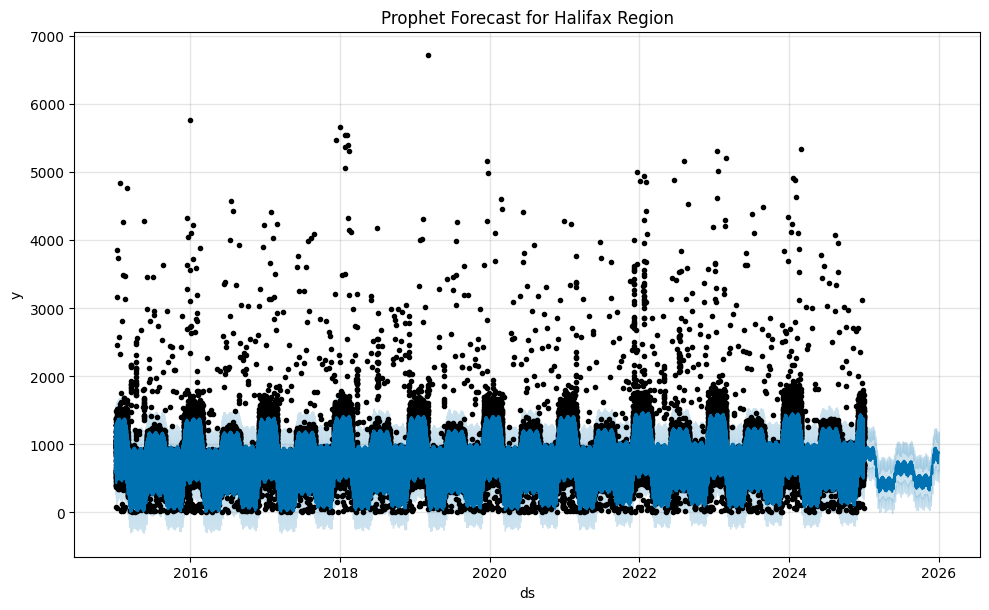

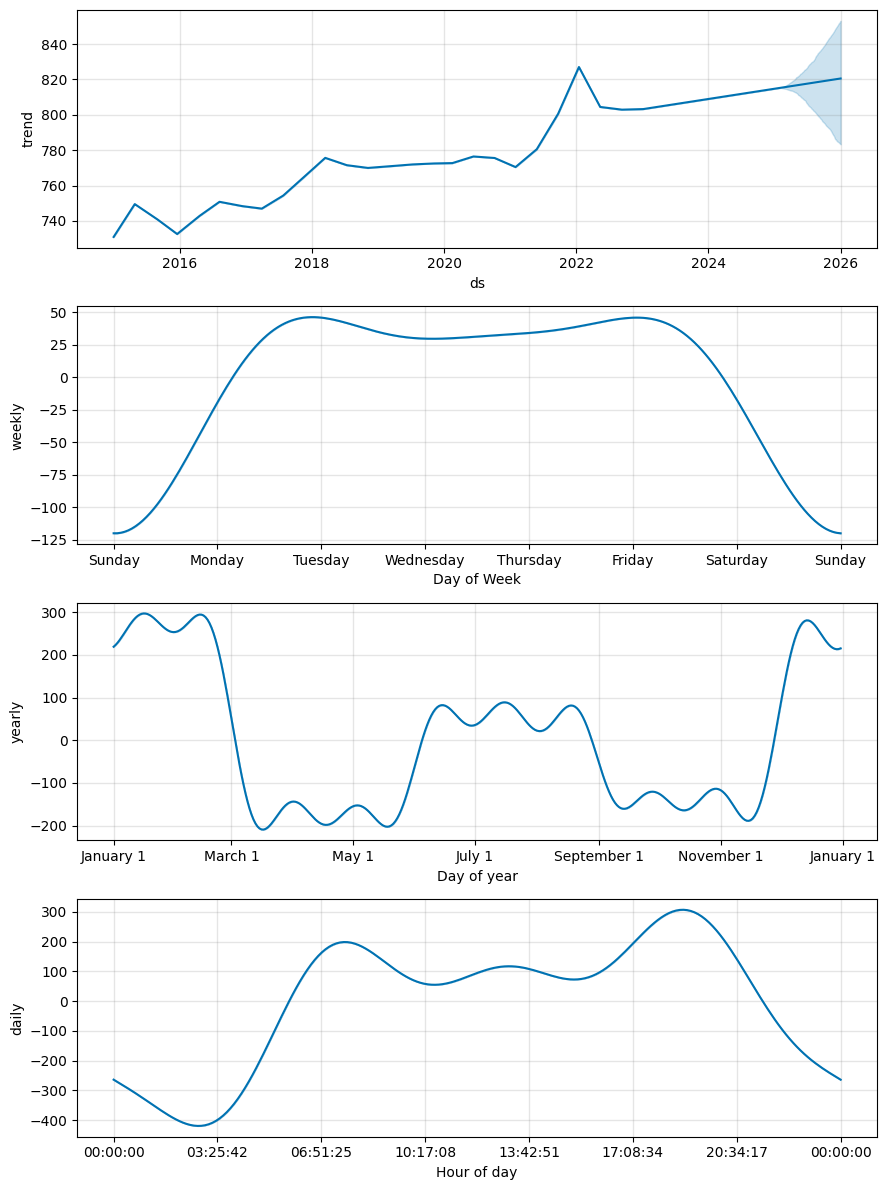

In [36]:
# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast for Halifax Region")
plt.show()

# Plot forecast components
fig2 = model.plot_components(forecast)
plt.show()


## LSTM Model for Halifax Region

### Why LSTM for Energy Forecasting?
LSTM (Long Short-Term Memory) networks capture long-term dependencies and non-linear temporal patterns in time series data, making them suitable for energy forecasting where daily/weekly/seasonal patterns and temporal dependencies are important.

### Data Preparation for LSTM
We'll normalize the target (`consumption_kwh`) with MinMaxScaler, create sliding windows (24-hour input to predict the next hour), and split the sequences into train/validation/test sets (60/20/20) preserving time order.

### Model Architecture
We'll use a stacked LSTM architecture with dropout for regularization:
- LSTM(100) -> Dropout(0.2) -> LSTM(50) -> Dense(1)

### Training and Evaluation
We'll use Adam optimizer, MSE loss, and track MAE/RMSE during evaluation. We'll use EarlyStopping and ModelCheckpoint during training.

### Results Visualization
We'll plot training/validation loss and actual vs predicted values and save plots to the `output/` directory.


In [37]:
# Data Preparation for LSTM
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os
import matplotlib.pyplot as plt
import joblib

# Ensure OUTPUT_DIR is defined (it is in earlier cells); otherwise define it
try:
    OUTPUT_DIR
except NameError:
    from pathlib import Path
    ROOT_DIR = Path.cwd().parent
    OUTPUT_DIR = ROOT_DIR / "output"

# Use Halifax data prepared earlier if available; otherwise re-create
try:
    halifax_data
except NameError:
    halifax_data = df[df['region'] == 'Halifax']

# Work on the consumption series and ensure it's sorted by timestamp
series = halifax_data['consumption_kwh'].sort_index()
print(f"Halifax series shape: {series.shape}")

# Optionally resample to hourly to enforce regular spacing (if needed)
# series = series.resample('H').mean().interpolate()

# Convert to numpy array
values = series.values.reshape(-1, 1).astype('float32')

# Normalize using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)

# Save scaler for inverse transforms later
scaler_path = os.path.join(str(OUTPUT_DIR), 'lstm_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Saved MinMaxScaler to: {scaler_path}")

# Create sequences: 24-hour windows to predict next hour
window_size = 24  # input sequence length (24 hours)
step = 1
X = []
y = []
for i in range(0, len(values_scaled) - window_size, step):
    X.append(values_scaled[i:i+window_size])
    y.append(values_scaled[i+window_size])
X = np.array(X)
y = np.array(y)

print(f"Created sequences -> X: {X.shape}, y: {y.shape}")

# Train / Val / Test split (60/20/20) — preserve time order
n_samples = X.shape[0]
train_end = int(n_samples * 0.6)
val_end = int(n_samples * 0.8)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Save a small diagnostic plot comparing original and scaled series (first 200 points)
plt.figure(figsize=(10, 4))
plt.plot(values[:200], label='original')
plt.plot(scaler.inverse_transform(values_scaled[:200]), label='scaled->inv')
plt.title('Original vs Scaled (first 200 points)')
plt.legend()
plot_path = OUTPUT_DIR / 'lstm_data_scaled.png'
plt.savefig(plot_path, bbox_inches='tight')
plt.close()
print(f"Saved diagnostic plot to: {plot_path}")

# Show a small sample of data prepared
print('Sample X[0] (first window, first 5 values):')
print(X_train[0][:5].flatten())
print('Sample y[0] (first target, inverse-scaled):')
print(scaler.inverse_transform(y_train[0].reshape(1, -1)))


Halifax series shape: (87672,)
Saved MinMaxScaler to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/lstm_scaler.pkl
Created sequences -> X: (87648, 24, 1), y: (87648, 1)
Train: (52588, 24, 1), Val: (17530, 24, 1), Test: (17530, 24, 1)
Saved diagnostic plot to: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/lstm_data_scaled.png
Sample X[0] (first window, first 5 values):
[0.06781612 0.08621788 0.05995389 0.05823404 0.06406965]
Sample y[0] (first target, inverse-scaled):
[[605.35]]


In [39]:
# Section B: PyTorch Model Definition (LSTM)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import math

# Check device/GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden1=100, hidden2=50, dropout=0.2):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(input_size=hidden1, hidden_size=hidden2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden2, 1)
    def forward(self, x):
        out1, _ = self.lstm1(x)
        out1 = self.dropout1(out1)
        out2, _ = self.lstm2(out1)
        out = out2[:, -1, :]
        out = self.dropout2(out)
        out = self.fc(out)
        return out

model = LSTMForecaster().to(device)
print('\nPyTorch model structure:')
print(model)


Device: cuda

PyTorch model structure:
LSTMForecaster(
  (lstm1): LSTM(1, 100, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(100, 50, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [40]:
# Section C: Training (SHORT validation run - 5 epochs)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import joblib
import numpy as np
import matplotlib.pyplot as plt
import os

# Prepare datasets and loaders (convert numpy arrays from data-prep)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

# Training setup
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

checkpoint_path = os.path.join(str(OUTPUT_DIR), 'lstm_model_torch_checkpoint.pt')
model_path = os.path.join(str(OUTPUT_DIR), 'lstm_model_halifax_torch.pt')

epochs = 5
best_val = float('inf')
train_losses = []
val_losses = []

for epoch in range(1, epochs+1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_loader.dataset)
    train_losses.append(train_loss)

    # validation
    model.eval()
    vrun = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            vrun += loss.item() * xb.size(0)
    val_loss = vrun / len(val_loader.dataset)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}/{epochs} - train_loss: {train_loss:.6f}, val_loss: {val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), checkpoint_path)

# Save final model
torch.save(model.state_dict(), model_path)
print('Saved PyTorch model to', model_path)


Epoch 1/5 - train_loss: 0.001830, val_loss: 0.001587
Epoch 2/5 - train_loss: 0.001232, val_loss: 0.001677
Epoch 3/5 - train_loss: 0.001163, val_loss: 0.001495
Epoch 4/5 - train_loss: 0.001139, val_loss: 0.001490
Epoch 5/5 - train_loss: 0.001115, val_loss: 0.001402
Saved PyTorch model to /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/lstm_model_halifax_torch.pt


In [41]:
# Section D: Evaluation & Visualization (PyTorch)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
with torch.no_grad():
    preds = model(X_test_t.to(device)).cpu().numpy()

y_pred = scaler.inverse_transform(preds)
y_true = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = math.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
print(f"Test MAE: {mae:.3f}, RMSE: {rmse:.3f}, MAPE: {mape:.3f}%")

# Record metrics using calculate_metrics
calculate_metrics(y_true=y_true.flatten(), y_pred=y_pred.flatten(), model_name='LSTM (PyTorch)')

# Loss plot
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.legend(); plt.title('LSTM Loss (short run - PyTorch)')
plt.savefig(OUTPUT_DIR / 'lstm_loss_curves_halifax_torch_short.png')
plt.close()
plt.show()

# Predictions plot
plt.figure(figsize=(12,5))
plt.plot(y_true.flatten(), label='actual')
plt.plot(y_pred.flatten(), label='predicted', alpha=0.7)
plt.legend(); plt.title('LSTM Predictions (short run - PyTorch)')
plt.savefig(OUTPUT_DIR / 'lstm_predictions_halifax_torch_short.png')
plt.close()
plt.show()

# Model file size
size_mb = os.path.getsize(model_path) / (1024*1024)
print(f"Model file size: {size_mb:.2f} MB")




Test MAE: 134.292, RMSE: 241.812, MAPE: 76.949%


NameError: name 'calculate_metrics' is not defined